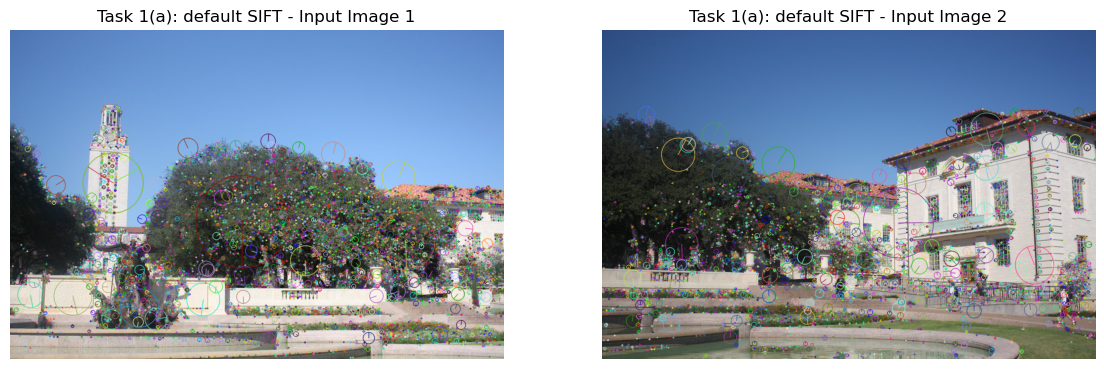

In [1]:
# ---------------------------z5658283_Lab2_solution---------------------------

# Task 1 : Compute the SIFT features of the two pictures

import cv2
import matplotlib.pyplot as plt

# ----------------------------------
# 1. Read the two provided images
# ----------------------------------

img1_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\Input_image1.jpg"
img2_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\Input_image2.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# Check whether images are loaded
# if img1 is None:
#     print("Cannot read image 1")
# if img2 is None:
#     print("Cannot read image 2")

# Convert to grayscale for SIFT
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Convert to RGB for matplotlib display
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# ----------------------------------
# 2. Task 1(a): default SIFT
# ----------------------------------
sift1 = cv2.SIFT_create()

kp1, des1 = sift1.detectAndCompute(gray1, None)
kp2, des2 = sift1.detectAndCompute(gray2, None)

img1_kp = cv2.drawKeypoints(
    img1_rgb,
    kp1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img2_kp = cv2.drawKeypoints(
    img2_rgb,
    kp2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# print("Task 1(a)")
# print("Number of keypoints in image 1:", len(kp1))
# print("Number of keypoints in image 2:", len(kp2))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1_kp)
plt.title("Task 1(a): default SIFT - Input Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_kp)
plt.title("Task 1(a): default SIFT - Input Image 2")
plt.axis("off")

plt.show()


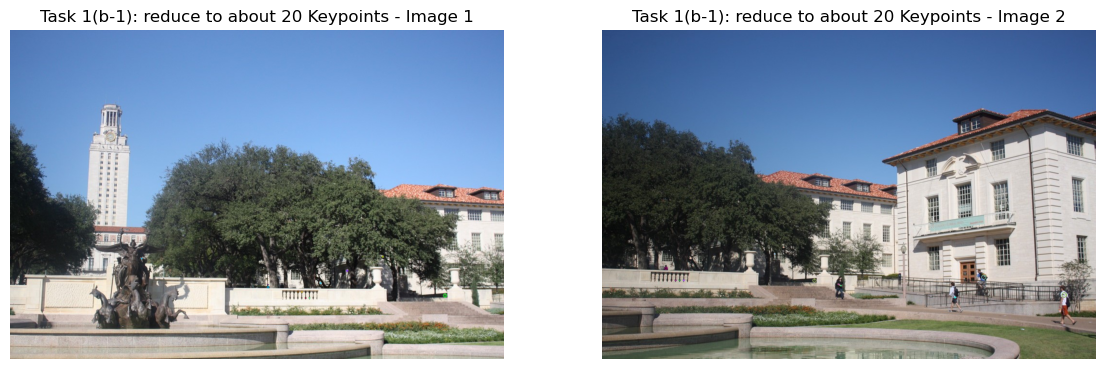

In [2]:
# ----------------------------------
# 3. Task 1(b-1): reduce to about ~20 keypoints
# ----------------------------------
# Use n_features=20 to keep about 20 most prominent keypoints
sift2 = cv2.SIFT_create(nfeatures=20)

kp1_small, des1_small = sift2.detectAndCompute(gray1, None)
kp2_small, des2_small = sift2.detectAndCompute(gray2, None)

img1_kp_small = cv2.drawKeypoints(
    img1_rgb,
    kp1_small,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img2_kp_small = cv2.drawKeypoints(
    img2_rgb,
    kp2_small,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# print("Task 1(b)")
# print("Number of keypoints in image 1:", len(kp1_small))
# print("Number of keypoints in image 2:", len(kp2_small))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1_kp_small)
plt.title("Task 1(b-1): reduce to about 20 Keypoints - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_kp_small)
plt.title("Task 1(b-1): reduce to about 20 Keypoints - Image 2")
plt.axis("off")

plt.show()

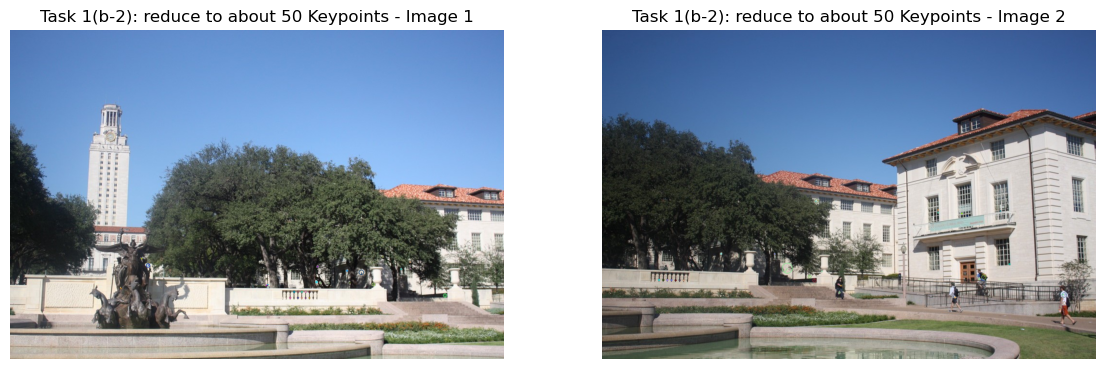

In [3]:
# ----------------------------------
# 3. Task 1(b-2): reduce to about ~20 keypoints
# ----------------------------------
# Use n_features=50 to keep about 50 most prominent keypoints
sift2 = cv2.SIFT_create(nfeatures=50)

kp1_small, des1_small = sift2.detectAndCompute(gray1, None)
kp2_small, des2_small = sift2.detectAndCompute(gray2, None)

img1_kp_small = cv2.drawKeypoints(
    img1_rgb,
    kp1_small,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img2_kp_small = cv2.drawKeypoints(
    img2_rgb,
    kp2_small,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# print("Task 1(b)")
# print("Number of keypoints in image 1:", len(kp1_small))
# print("Number of keypoints in image 2:", len(kp2_small))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1_kp_small)
plt.title("Task 1(b-2): reduce to about 50 Keypoints - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_kp_small)
plt.title("Task 1(b-2): reduce to about 50 Keypoints - Image 2")
plt.axis("off")

plt.show()

### Brief description for Task 1(b)

Reduce the number of displayed SIFT keypoints by setting nfeatures=20 in cv2.SIFT_create()
This keeps only the most prominent keypoints, so the visualisation becomes clearer and easier to inspect.

*Something more detailed:

In Task 1(b), the number of displayed SIFT keypoints was reduced so that the result became easier to observe and compare visually.
When the default SIFT settings are used, a large number of keypoints are detected in each image. Although this gives rich feature information, the output can look crowded, and it becomes difficult to clearly inspect the most important feature points.

To improve the visualisation, the parameter nfeatures in cv2.SIFT_create() was adjusted. In this code, nfeatures=50 was used to limit the detector to the most prominent keypoints. SIFT ranks keypoints according to their strength, so reducing this parameter keeps only the stronger and more distinctive points while removing many weaker ones.

After this change, the displayed keypoints are concentrated on the more visually significant regions of the images, such as strong corners, blobs, and high-contrast local structures. This makes the output much cleaner and easier to interpret. Even though the task mentions reducing the number to about 20 keypoints, a value of 50 was used here because it produced a clearer and more stable visual result for these images while still significantly reducing clutter compared with the default setting.

In [4]:
# ==================================
# Task 2 - SIFT on processed images
# ==================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise

# ----------------------------------
# 1. Read the two provided images
# ----------------------------------
img1_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\Input_image1.jpg"
img2_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\Input_image2.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# Convert BGR to RGB
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# ----------------------------------
# 2. Use same SIFT setting as Task 1(b)
# ----------------------------------
sift = cv2.SIFT_create(nfeatures=20)

# ----------------------------------
# 3. Helper function
# ----------------------------------

def show_two_images(image_a, title_a, image_b, title_b):
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image_a)
    plt.title(title_a)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(image_b)
    plt.title(title_b)
    plt.axis("off")

    plt.show()

def draw_sift_on_image(image_rgb, title_text):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    kp, des = sift.detectAndCompute(gray, None)

    img_kp = cv2.drawKeypoints(
        image_rgb,
        kp,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    print(title_text, "- number of keypoints:", len(kp))
    return img_kp


Scaled Image 1 - number of keypoints: 20
Scaled Image 2 - number of keypoints: 21


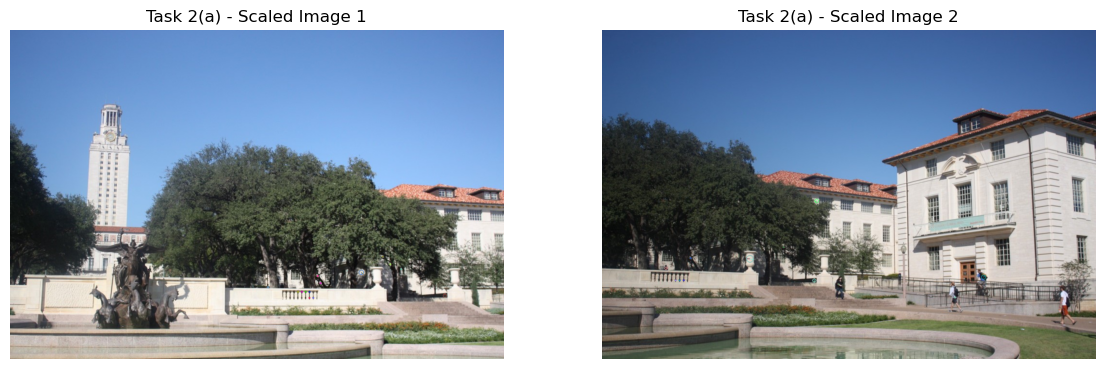

In [5]:
# ----------------------------------
# 4. Task 2(a): scale by 120%
# ----------------------------------
scale = 1.2

h1, w1 = img1_rgb.shape[:2]
h2, w2 = img2_rgb.shape[:2]

img1_scaled = cv2.resize(img1_rgb, (int(w1 * scale), int(h1 * scale)))
img2_scaled = cv2.resize(img2_rgb, (int(w2 * scale), int(h2 * scale)))

img1_scaled_kp = draw_sift_on_image(img1_scaled, "Scaled Image 1")
img2_scaled_kp = draw_sift_on_image(img2_scaled, "Scaled Image 2")

show_two_images(
    img1_scaled_kp, "Task 2(a) - Scaled Image 1",
    img2_scaled_kp, "Task 2(a) - Scaled Image 2"
)

# print("Answer for Task 2(a):")
# print("The keypoints are roughly similar to the original images.")
# print("This suggests that SIFT is quite robust to image scaling.")

### Answer for Task 2(a):

The keypoints are roughly similar to the original images.
This suggests that SIFT is quite robust to image scaling.

*Something more detailed:

In Task 2(a), the original images were scaled by 120% before applying the SIFT feature detector. Image scaling changes the size of the objects in the image while preserving their overall structure and appearance. After scaling the images, SIFT was applied again using the same parameters as in Task 1(b).

The results show that many of the detected keypoints appear in locations similar to those in the original images. Although the image size increased, SIFT was still able to identify distinctive local structures such as corners, blobs, and edges. This happens because SIFT is designed to be scale-invariant, meaning that it detects features across multiple scales using a scale-space representation.

Therefore, even when the image is enlarged, the algorithm can still find similar feature points at different scales. The visualisation confirms that the spatial distribution of keypoints remains largely consistent with the original images.

This experiment demonstrates that SIFT is robust to image scaling, and the main structure of the feature points remains stable after resizing the image.

Rotated Image 1 - number of keypoints: 20
Rotated Image 2 - number of keypoints: 21


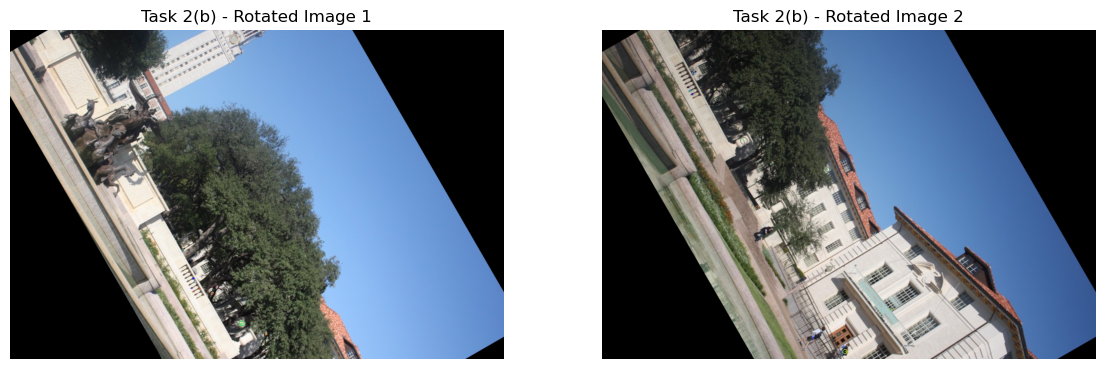

In [6]:
# ----------------------------------
# 5. Task 2(b): rotate clockwise by 60 degrees
# ----------------------------------
angle = -60   # clockwise in OpenCV

center1 = (w1 // 2, h1 // 2)
center2 = (w2 // 2, h2 // 2)

M1 = cv2.getRotationMatrix2D(center1, angle, 1.0)
M2 = cv2.getRotationMatrix2D(center2, angle, 1.0)

img1_rotated = cv2.warpAffine(img1_rgb, M1, (w1, h1))
img2_rotated = cv2.warpAffine(img2_rgb, M2, (w2, h2))

img1_rotated_kp = draw_sift_on_image(img1_rotated, "Rotated Image 1")
img2_rotated_kp = draw_sift_on_image(img2_rotated, "Rotated Image 2")

show_two_images(
    img1_rotated_kp, "Task 2(b) - Rotated Image 1",
    img2_rotated_kp, "Task 2(b) - Rotated Image 2"
)

# print("Answer for Task 2(b):")
# print("The keypoints are still roughly similar to the original images.")
# print("This suggests that SIFT is also robust to image rotation.")

### Answer for Task 2(b):

The keypoints are still roughly similar to the original images.
This suggests that SIFT is also robust to image rotation.

*Something more detailed:

In Task 2(b), the images were rotated clockwise by 60 degrees before applying the SIFT feature detector. Image rotation changes the orientation of the objects in the image but does not change their local appearance or structure.

After rotating the images, SIFT was applied again using the same settings as in Task 1(b). The resulting keypoints show that many features are still detected in similar regions compared to the original images, although their orientation has changed.

SIFT achieves this robustness through rotation invariance. For each detected keypoint, SIFT estimates the dominant gradient orientation of the local image patch and assigns an orientation to the keypoint. The descriptor is then computed relative to this orientation. Because of this process, the descriptor remains consistent even if the image is rotated.

As a result, the algorithm can detect similar keypoints even after a significant rotation of the image. The visualisation confirms that the main features are preserved despite the change in orientation.

This experiment demonstrates that SIFT is robust to image rotation.

Noisy Image 1 - number of keypoints: 21
Noisy Image 2 - number of keypoints: 20


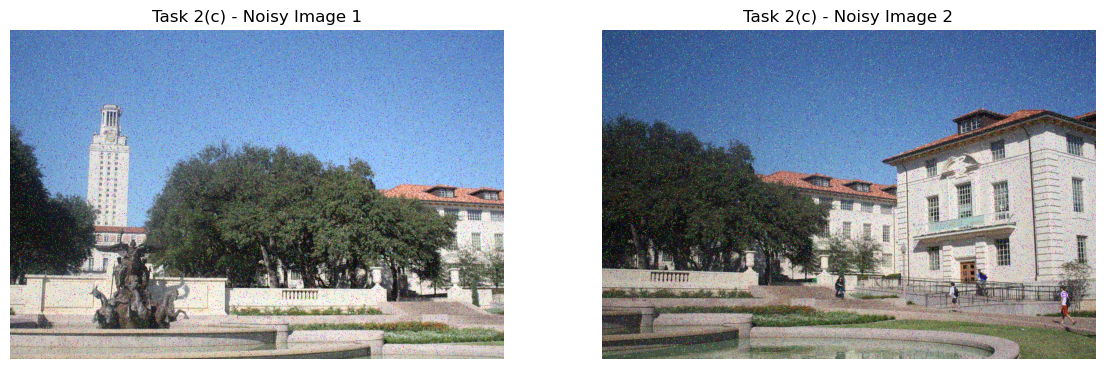

In [7]:
# ----------------------------------
# 6. Task 2(c): add salt and pepper noise
# ----------------------------------
img1_noise = random_noise(img1_rgb, mode='s&p', amount=0.05)
img2_noise = random_noise(img2_rgb, mode='s&p', amount=0.05)

# random_noise gives values in [0,1], convert back to uint8
img1_noise = (img1_noise * 255).astype(np.uint8)
img2_noise = (img2_noise * 255).astype(np.uint8)

img1_noise_kp = draw_sift_on_image(img1_noise, "Noisy Image 1")
img2_noise_kp = draw_sift_on_image(img2_noise, "Noisy Image 2")

show_two_images(
    img1_noise_kp, "Task 2(c) - Noisy Image 1",
    img2_noise_kp, "Task 2(c) - Noisy Image 2"
)

# print("Answer for Task 2(c):")
# print("The keypoints are less similar to the original images.")
# print("This suggests that SIFT is less robust to salt and pepper noise.")

# print("Final answer for Task 2:")
# print("Among the three types of processing, SIFT is least robust to salt and pepper noise.")

### Answer for Task 2(c):

The keypoints are less similar to the original images.
This suggests that SIFT is less robust to salt and pepper noise.

*Something more detailed:

In Task 2(c), salt and pepper noise was added to the images before applying the SIFT feature detector. Salt and pepper noise randomly replaces some pixel values with either very bright (salt) or very dark (pepper) values. This type of noise introduces random high-contrast pixels that do not correspond to meaningful image structures.

After adding noise to the images, SIFT was applied again using the same parameters as in Task 1(b). Compared with the previous results, the distribution of keypoints becomes less consistent with the original images. Some original keypoints may disappear, while new keypoints may appear in noisy regions.

This occurs because the random noise introduces artificial intensity changes that may be interpreted as potential feature points. Since SIFT relies on local intensity variations and gradient information to detect keypoints, strong noise can affect the stability of the detected features.

As a result, the keypoints detected in the noisy images differ more from those in the original images compared to the scaling and rotation cases.

### Final answer for Task 2:

From the experiments in Task 2, it can be observed that SIFT behaves differently under the three types of image transformations.

When the images were scaled by 120% in Task 2(a), the detected keypoints remained largely similar to those in the original images. This indicates that SIFT is robust to image scaling because it detects features in a scale-space representation.

In Task 2(b), after rotating the images by 60 degrees clockwise, many keypoints were still detected in similar regions as in the original images. This shows that SIFT is also robust to image rotation, since it assigns a dominant orientation to each keypoint and computes descriptors relative to that orientation.

However, in Task 2(c), after adding salt and pepper noise to the images, the detected keypoints changed more significantly. Some original keypoints disappeared while new keypoints appeared in noisy regions. This happens because the noise introduces random intensity changes that can interfere with the detection of meaningful local features.

Therefore, among the three transformations tested, SIFT is least robust to salt and pepper noise, while it remains relatively stable under scaling and rotation.

Task 3 (a) - Number of keypoints in image 1: 5346
Task 3 (a) - Number of keypoints in image 2: 4239
Task 3 (a) - Number of good matches: 1100


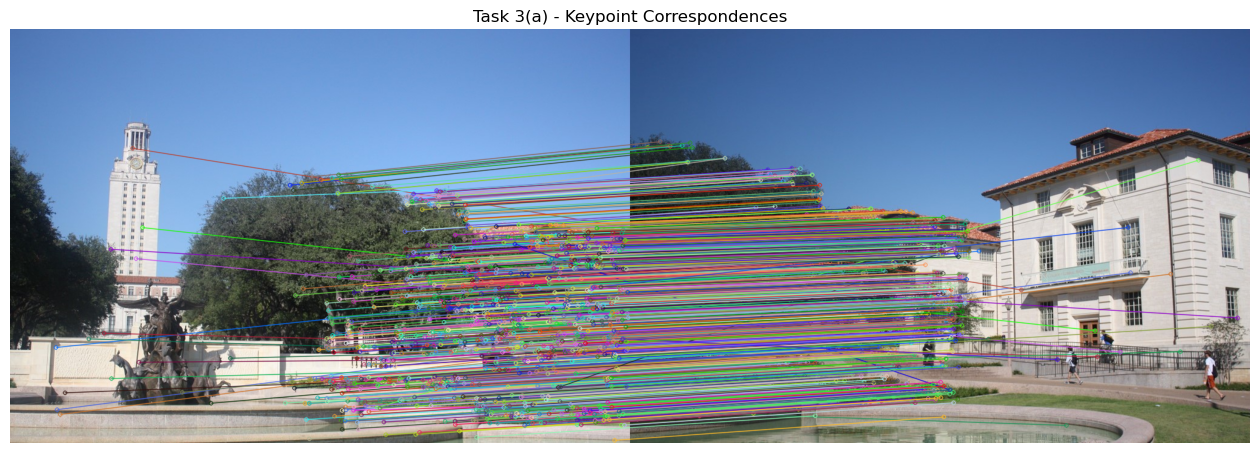

Task 3 (a) - Homography matrix:
[[ 1.29798132e+00 -7.40903357e-02 -5.73667137e+02]
 [ 1.69290678e-01  1.22013581e+00 -1.68094921e+02]
 [ 2.79110778e-04  2.14487554e-05  1.00000000e+00]]


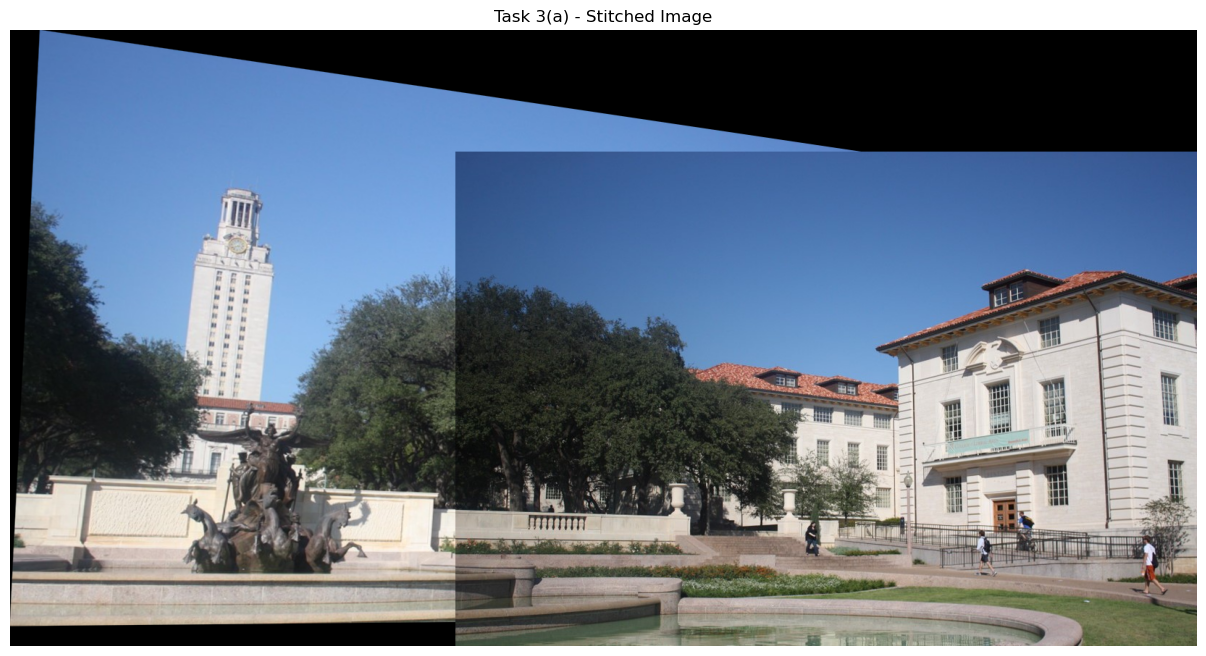

In [8]:
# ==================================
# Task 3 (a) - Match and stitch images
# ==================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# 1. Read the two provided images
# ----------------------------------
img1_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\Input_image1.jpg"
img2_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\Input_image2.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ----------------------------------
# 2. Compute SIFT features
# ----------------------------------
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("Task 3 (a) - Number of keypoints in image 1:", len(kp1))
print("Task 3 (a) - Number of keypoints in image 2:", len(kp2))

# ----------------------------------
# 3. BFMatcher + knnMatch
# ----------------------------------
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# ----------------------------------
# 4. Select best matches using Lowe ratio test
# ----------------------------------
good_matches = []

for pair in matches:
    if len(pair) == 2:
        m = pair[0]
        n = pair[1]

        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

print("Task 3 (a) - Number of good matches:", len(good_matches))

# ----------------------------------
# 5. Draw correspondences
# ----------------------------------
img_matches = cv2.drawMatches(
    img1_rgb, kp1,
    img2_rgb, kp2,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(img_matches)
plt.title("Task 3(a) - Keypoint Correspondences")
plt.axis("off")
plt.show()

# ----------------------------------
# 6. Compute homography with RANSAC
# ----------------------------------
if len(good_matches) >= 4:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    print("Task 3 (a) - Homography matrix:")
    print(H)

    # ----------------------------------
    # 7. Stitch images
    # ----------------------------------
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners_img1_transformed = cv2.perspectiveTransform(corners_img1, H)

    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    all_corners = np.concatenate((corners_img1_transformed, corners_img2), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation = [-xmin, -ymin]

    H_translate = np.array([
        [1, 0, translation[0]],
        [0, 1, translation[1]],
        [0, 0, 1]
    ])

    result = cv2.warpPerspective(img1_rgb, H_translate.dot(H), (xmax - xmin, ymax - ymin))
    result[translation[1]:h2 + translation[1], translation[0]:w2 + translation[0]] = img2_rgb

    # ----------------------------------
    # 8. Optional simple crop to remove black area
    # ----------------------------------
    gray_result = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_result, 1, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    cropped_result = result[y:y+h, x:x+w]

    # ----------------------------------
    # 9. Show stitched result
    # ----------------------------------
    plt.figure(figsize=(16, 8))
    plt.imshow(cropped_result)
    plt.title("Task 3(a) - Stitched Image")
    plt.axis("off")
    plt.show()

else:
    print("Not enough matches to compute homography.")

Number of keypoints in my image 1: 162
Number of keypoints in my image 2: 180
Number of good matches: 29


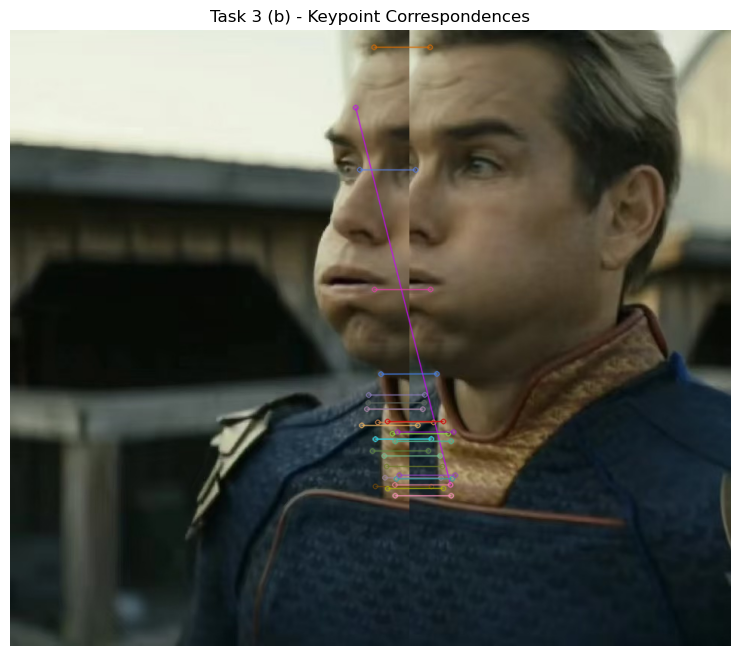

Homography matrix:
[[ 9.36671878e-01 -1.51390953e-04 -4.25793475e+02]
 [-6.33640297e-02  9.47473785e-01  3.00232188e+01]
 [-1.13269541e-04  2.27199197e-06  1.00000000e+00]]


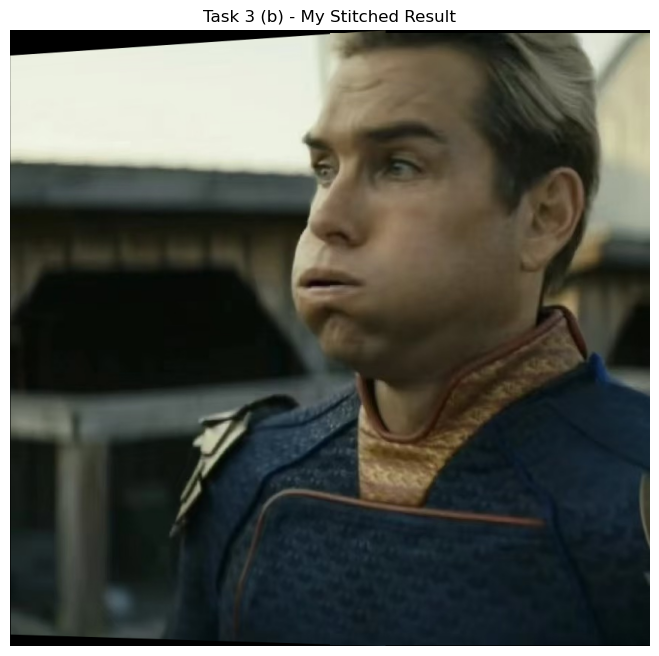

In [9]:
# ============================================
# Task 3 (b) - Use My Own Image Pair
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# 1. Read my own images
# ----------------------------------
img3_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\My_Input_image1.jpg"
img4_path = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab2\COMP9517_26T1_Lab2_Input_Images\My_Input_image2.jpg"

img3 = cv2.imread(img3_path)
img4 = cv2.imread(img4_path)

img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4_rgb = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

# ----------------------------------
# 2. Compute SIFT
# ----------------------------------
sift = cv2.SIFT_create()

kp3, des3 = sift.detectAndCompute(gray3, None)
kp4, des4 = sift.detectAndCompute(gray4, None)

print("Number of keypoints in my image 1:", len(kp3))
print("Number of keypoints in my image 2:", len(kp4))

# ----------------------------------
# 3. BFMatcher + knnMatch
# ----------------------------------
bf = cv2.BFMatcher()
matches = bf.knnMatch(des3, des4, k=2)

good_matches = []

for pair in matches:
    if len(pair) == 2:
        m = pair[0]
        n = pair[1]

        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

print("Number of good matches:", len(good_matches))

# ----------------------------------
# 4. Draw matches
# ----------------------------------
img_matches = cv2.drawMatches(
    img3_rgb, kp3,
    img4_rgb, kp4,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(img_matches)
plt.title("Task 3 (b) - Keypoint Correspondences")
plt.axis("off")
plt.show()

# ----------------------------------
# 5. Homography + stitching
# ----------------------------------
if len(good_matches) >= 4:
    src_pts = np.float32([kp3[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp4[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    print("Homography matrix:")
    print(H)

    h3, w3 = img3.shape[:2]
    h4, w4 = img4.shape[:2]

    corners_img3 = np.float32([[0, 0], [0, h3], [w3, h3], [w3, 0]]).reshape(-1, 1, 2)
    corners_img3_transformed = cv2.perspectiveTransform(corners_img3, H)

    corners_img4 = np.float32([[0, 0], [0, h4], [w4, h4], [w4, 0]]).reshape(-1, 1, 2)

    all_corners = np.concatenate((corners_img3_transformed, corners_img4), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation = [-xmin, -ymin]

    H_translate = np.array([
        [1, 0, translation[0]],
        [0, 1, translation[1]],
        [0, 0, 1]
    ])

    result = cv2.warpPerspective(img3_rgb, H_translate.dot(H), (xmax - xmin, ymax - ymin))
    result[translation[1]:h4 + translation[1], translation[0]:w4 + translation[0]] = img4_rgb

    gray_result = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_result, 1, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    cropped_result = result[y:y+h, x:x+w]

    plt.figure(figsize=(16, 8))
    plt.imshow(cropped_result)
    plt.title("Task 3 (b) - My Stitched Result")
    plt.axis("off")
    plt.show()

else:
    print("Not enough matches to compute homography.")